Переменные 'model', 'q_exp', 'R_exp', 'error_exp' и их numpy-версии доступны для следующей ячейки.
Переменные 'model', 'q_exp', 'R_exp', 'error_exp' и их numpy-версии доступны для следующей ячейки.
--- Расчет кривой для начальных параметров (с оксидным слоем и ФИКСИРОВАННЫМ q-shift) ---
torch.Size([2261, 3])
tensor([0.0407, 0.0411, 0.0416,  ..., 0.7076, 0.7083, 0.7089],
       dtype=torch.float64)


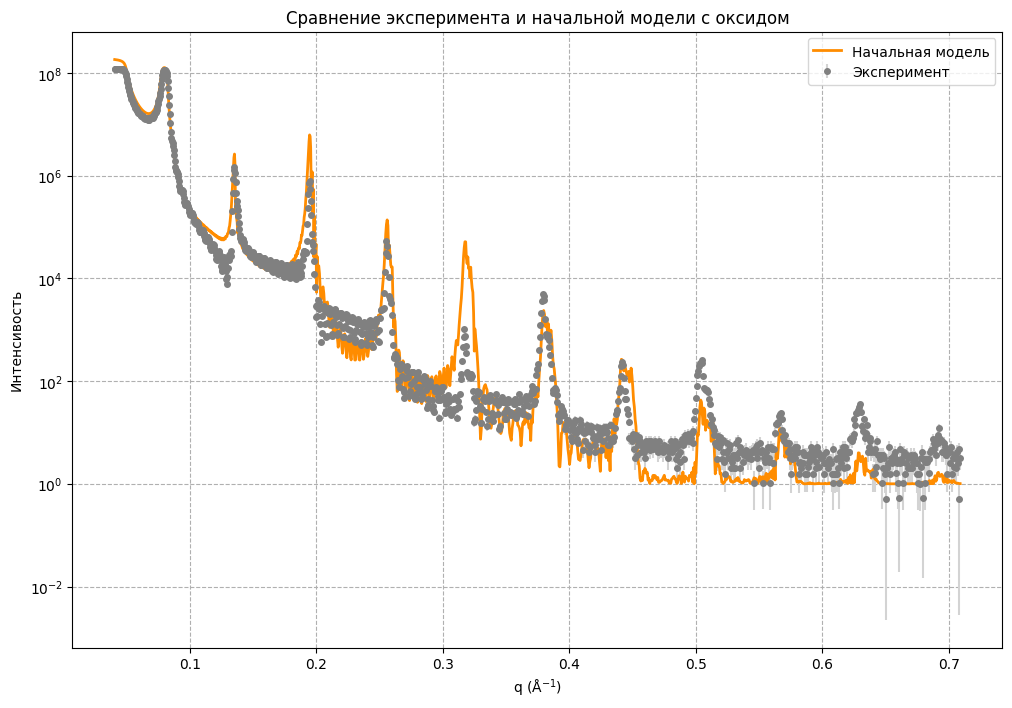


--- Профиль SLD для начальных параметров ---


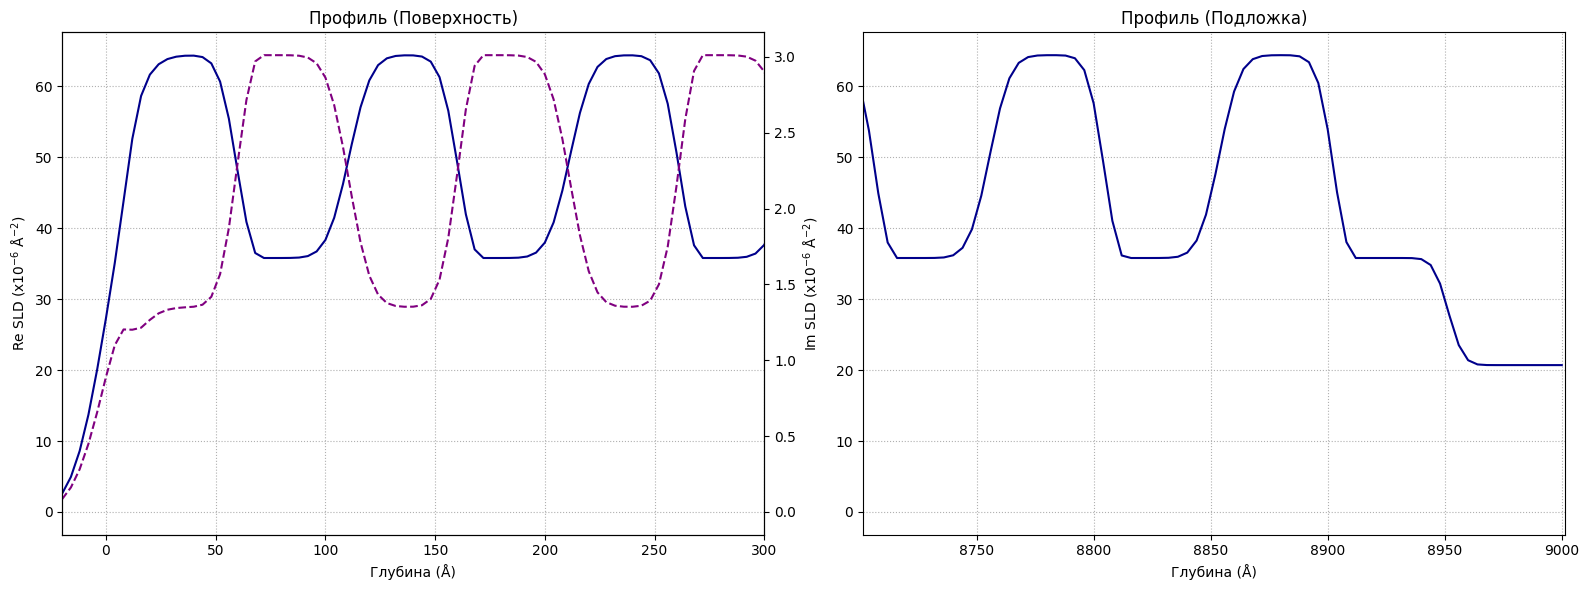


Ячейка 1 выполнена. Модель с оксидным слоем создана и готова к оптимизации.
Переменные 'model', 'q_exp', 'R_exp', 'error_exp' и их numpy-версии доступны для следующей ячейки.


In [1]:
# Запустите эту ячейку первой
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import display, clear_output

# --- Шаг 1: Константы и ядро расчета ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TINY = 1.0e-12
np_pi = np.pi
SQRT_2 = np.sqrt(2.0)
SQRT_2_PI = np.sqrt(2.0 * np.pi)

NPOINTS=1200
Slice_thickness=4
SDVIG=0.002

# --- БЛОК: Удобный ввод всех начальных параметров ---
# Все стартовые значения для оптимизации собраны в одном месте.
initial_params = {
    # Структурные параметры (толщины слоев в Å)
    "n_pairs": 90,
    "d_nio": 10.0,
    "d_ni_surface_after_ox": 53.3,
    "d_ni_substrate": 52.0,
    "d_ti_surface": 47.4,
    "d_ti_substrate": 46.0,

    # Параметры шероховатости (sigma в Å) и асимметрии (alpha)
    "sigma_air_nio": 12.0,
    "sigma_nio_ni": 4.0,
    "sigma_ni_ti_surface": 7.0,
    "sigma_ni_ti_substrate": 6.0,
    "sigma_ti_ni_surface": 8.0,
    "sigma_ti_ni_substrate": 7.0,
    "sigma_si_ti": 5.0,
    "alpha_air_nio": 0.01,
    "alpha_nio_ni": 0.01,
    "alpha_ni_ti": -1.01,
    "alpha_ti_ni": 0.01,
    "alpha_si_ti": 0.01,

    # Мультипликаторы для плотностей длин рассеяния (SLD)
    "nio_mult": 1.0,
    "ni_mult": 1.0,
    "ti_mult": 1.0,
    "si_mult": 1.0,

    # Инструментальные и подгоночные параметры
    "scale_init": 8.3,
    "bkg_init": 0.0,
    "q_shift_init": 0.0, # <-- Это значение будет ФИКСИРОВАННЫМ
}
# --- КОНЕЦ БЛОКА ---


def reflec_new(q, layers, bkg, scale):
    """Функция расчета рефлектометрии методом матриц Парратта."""
    print(q)
    xx = torch.as_tensor(q, dtype=torch.complex128, device=device).view(-1); nlayers = layers.size(0) - 2; npnts = xx.size(0)
    kn = torch.zeros((npnts, nlayers + 2), dtype=torch.complex128, device=device); sld = torch.zeros(nlayers + 2, dtype=torch.complex128, device=device)
    sld[1:] += ((layers[1:, 1] - layers[0, 1]) + 1j * (torch.abs(layers[1:, 2]) + TINY)) * 1.0e-6
    kn[:] = torch.sqrt((xx[:, None] ** 2.0) / 4.0 - 4.0 * torch.tensor(np_pi, device=device) * sld)
    rj = (kn[:, :-1] - kn[:, 1:]) / (kn[:, :-1] + kn[:, 1:])
    if nlayers > 0:
        mi00 = torch.ones((npnts, nlayers + 1), dtype=torch.complex128, device=device); mi00[:, 1:] = torch.exp(kn[:, 1:-1] * 1j * torch.abs(layers[1:-1, 0]))
        mi11 = 1.0 / mi00; mi10 = rj * mi00; mi01 = rj * mi11; mrtot00, mrtot01, mrtot10, mrtot11 = mi00[:, 0], mi01[:, 0], mi10[:, 0], mi11[:, 0]
        for idx in range(1, nlayers + 1):
            p0 = mrtot00 * mi00[:, idx] + mrtot10 * mi01[:, idx]; p1 = mrtot00 * mi10[:, idx] + mrtot10 * mi11[:, idx]; mrtot00, mrtot10 = p0, p1
            p0 = mrtot01 * mi00[:, idx] + mrtot11 * mi01[:, idx]; p1 = mrtot01 * mi10[:, idx] + mrtot11 * mi11[:, idx]; mrtot01, mrtot11 = p0, p1
    else: mrtot00 = torch.ones(npnts, dtype=torch.complex128, device=device); mrtot01 = rj[:,0]
    r = mrtot01 / mrtot00; reflectivity = r * torch.conj(r); reflectivity *= 10**(scale); reflectivity += 10**bkg
    return torch.real(reflectivity)


# --- Шаг 2: Дифференцируемая модель с оксидным слоем и ФИКСИРОВАННЫМ сдвигом по q ---
class ReflectivityModel(nn.Module):
    """Модель с поверхностным слоем оксида никеля."""
    def __init__(self, params: dict):
        super().__init__()
        self.n_pairs = params['n_pairs']

        self.register_buffer('sld_nio_re_bulk', torch.tensor(55.0, dtype=torch.float64, device=device)); self.register_buffer('sld_nio_im_bulk', torch.tensor(1.8, dtype=torch.float64, device=device))
        self.register_buffer('sld_ni_re_bulk', torch.tensor(64.4, dtype=torch.float64, device=device)); self.register_buffer('sld_ni_im_bulk', torch.tensor(1.351, dtype=torch.float64, device=device))
        self.register_buffer('sld_ti_re_bulk', torch.tensor(35.8, dtype=torch.float64, device=device)); self.register_buffer('sld_ti_im_bulk', torch.tensor(3.011, dtype=torch.float64, device=device))
        self.register_buffer('sld_si_re_bulk', torch.tensor(20.7, dtype=torch.float64, device=device)); self.register_buffer('sld_si_im_bulk', torch.tensor(0.458, dtype=torch.float64, device=device))

        self.register_buffer('q_shift', torch.tensor(params['q_shift_init'], dtype=torch.float64, device=device))

        self.nio_mult = nn.Parameter(torch.tensor(params['nio_mult'], dtype=torch.float64, device=device))
        self.ni_mult = nn.Parameter(torch.tensor(params['ni_mult'], dtype=torch.float64, device=device))
        self.ti_mult = nn.Parameter(torch.tensor(params['ti_mult'], dtype=torch.float64, device=device))
        self.si_mult = nn.Parameter(torch.tensor(params['si_mult'], dtype=torch.float64, device=device))
        self.d_nio = nn.Parameter(torch.tensor(params['d_nio'], dtype=torch.float64, device=device))
        self.d_ni_surface = nn.Parameter(torch.tensor(params['d_ni_surface_after_ox'], dtype=torch.float64, device=device))
        self.d_ni_substrate = nn.Parameter(torch.tensor(params['d_ni_substrate'], dtype=torch.float64, device=device))
        self.d_ti_surface = nn.Parameter(torch.tensor(params['d_ti_surface'], dtype=torch.float64, device=device))
        self.d_ti_substrate = nn.Parameter(torch.tensor(params['d_ti_substrate'], dtype=torch.float64, device=device))
        self.sigma_air_nio = nn.Parameter(torch.tensor(params['sigma_air_nio'], dtype=torch.float64, device=device))
        self.sigma_nio_ni = nn.Parameter(torch.tensor(params['sigma_nio_ni'], dtype=torch.float64, device=device))
        self.sigma_ni_ti_surface = nn.Parameter(torch.tensor(params['sigma_ni_ti_surface'], dtype=torch.float64, device=device))
        self.sigma_ni_ti_substrate = nn.Parameter(torch.tensor(params['sigma_ni_ti_substrate'], dtype=torch.float64, device=device))
        self.sigma_ti_ni_surface = nn.Parameter(torch.tensor(params['sigma_ti_ni_surface'], dtype=torch.float64, device=device))
        self.sigma_ti_ni_substrate = nn.Parameter(torch.tensor(params['sigma_ti_ni_substrate'], dtype=torch.float64, device=device))
        self.sigma_si_ti = nn.Parameter(torch.tensor(params['sigma_si_ti'], dtype=torch.float64, device=device))
        self.alpha_air_nio = nn.Parameter(torch.tensor(params['alpha_air_nio'], dtype=torch.float64, device=device))
        self.alpha_nio_ni = nn.Parameter(torch.tensor(params['alpha_nio_ni'], dtype=torch.float64, device=device))
        self.alpha_ni_ti = nn.Parameter(torch.tensor(params['alpha_ni_ti'], dtype=torch.float64, device=device))
        self.alpha_ti_ni = nn.Parameter(torch.tensor(params['alpha_ti_ni'], dtype=torch.float64, device=device))
        self.alpha_si_ti = nn.Parameter(torch.tensor(params['alpha_si_ti'], dtype=torch.float64, device=device))
        self.scale = nn.Parameter(torch.tensor(params['scale_init'], dtype=torch.float64, device=device))
        self.bkg = nn.Parameter(torch.tensor(params['bkg_init'], dtype=torch.float64, device=device))

        self.sld_air_re = torch.tensor(0.0, dtype=torch.float64, device=device)
        self.sld_air_im = torch.tensor(0.0, dtype=torch.float64, device=device)

    def _skew_erf_profile(self, z, z0, omega, alpha):
        x = (z - z0) / (omega + TINY); norm_cdf = 0.5 * (1.0 + torch.erf(x / SQRT_2))
        norm_pdf = torch.exp(-0.5 * x**2) / SQRT_2_PI; skew_correction = (alpha / (1 + alpha**2)**0.5) * norm_pdf
        return torch.clamp(norm_cdf - skew_correction, 0.0, 1.0)

    def _get_profile_and_slice(self, slice_thickness: float = Slice_thickness):
        sld_nio_re_eff = self.nio_mult * self.sld_nio_re_bulk; sld_nio_im_eff = self.nio_mult * self.sld_nio_im_bulk
        sld_ni_re_eff = self.ni_mult * self.sld_ni_re_bulk; sld_ni_im_eff = self.ni_mult * self.sld_ni_im_bulk
        sld_ti_re_eff = self.ti_mult * self.sld_ti_re_bulk; sld_ti_im_eff = self.ti_mult * self.sld_ti_im_bulk
        sld_si_re_eff = self.si_mult * self.sld_si_re_bulk; sld_si_im_eff = self.si_mult * self.sld_si_im_bulk
        t = torch.linspace(0.0, 1.0, self.n_pairs, dtype=torch.float64, device=device)
        d_ni = self.d_ni_surface * (1 - t) + self.d_ni_substrate * t; d_ti = self.d_ti_surface * (1 - t) + self.d_ti_substrate * t
        sigma_ni_ti = self.sigma_ni_ti_surface * (1 - t) + self.sigma_ni_ti_substrate * t; sigma_ti_ni = self.sigma_ti_ni_surface * (1 - t) + self.sigma_ti_ni_substrate * t
        materials_sld_re = [self.sld_air_re, sld_nio_re_eff, sld_ni_re_eff]; materials_sld_im = [self.sld_air_im, sld_nio_im_eff, sld_ni_im_eff]
        interfaces_z = [torch.tensor(0.0, device=device), self.d_nio]; omegas = [self.sigma_air_nio, self.sigma_nio_ni]; alphas = [self.alpha_air_nio, self.alpha_nio_ni]
        current_z = self.d_nio
        for i in range(self.n_pairs):
            current_z = current_z + d_ni[i]; interfaces_z.append(current_z); materials_sld_re.append(sld_ti_re_eff); materials_sld_im.append(sld_ti_im_eff); omegas.append(sigma_ni_ti[i]); alphas.append(self.alpha_ni_ti)
            current_z = current_z + d_ti[i]; interfaces_z.append(current_z); materials_sld_re.append(sld_ni_re_eff); materials_sld_im.append(sld_ni_im_eff); omegas.append(sigma_ti_ni[i]); alphas.append(self.alpha_ti_ni)
        materials_sld_re[-1] = sld_si_re_eff; materials_sld_im[-1] = sld_si_im_eff; omegas[-1] = self.sigma_si_ti; alphas[-1] = self.alpha_si_ti
        total_thickness = interfaces_z[-1]; start_z = (-5 * self.sigma_air_nio).item(); end_z = (total_thickness + 5 * self.sigma_si_ti).item()
        z_grid = torch.arange(start_z, end_z, slice_thickness, device=device, dtype=torch.float64)
        profiles = torch.stack([self._skew_erf_profile(z_grid, z0, o, a) for z0, o, a in zip(interfaces_z, omegas, alphas)])
        profile_sld_re = torch.zeros_like(z_grid); profile_sld_im = torch.zeros_like(z_grid)
        profile_sld_re += materials_sld_re[0] * (1.0 - profiles[0]); profile_sld_im += materials_sld_im[0] * (1.0 - profiles[0])
        for i in range(len(interfaces_z) - 1):
            profile_sld_re += materials_sld_re[i+1] * (profiles[i] - profiles[i+1]); profile_sld_im += materials_sld_im[i+1] * (profiles[i] - profiles[i+1])
        profile_sld_re += materials_sld_re[-1] * profiles[-1]; profile_sld_im += materials_sld_im[-1] * profiles[-1]
        sld_re_slices = (profile_sld_re[:-1] + profile_sld_re[1:]) / 2.0; sld_im_slices = (profile_sld_im[:-1] + profile_sld_im[1:]) / 2.0
        num_slices = sld_re_slices.shape[0]; thickness_col = torch.full((num_slices, 1), slice_thickness, dtype=torch.float64, device=device)
        sld_re_col = sld_re_slices.unsqueeze(1); sld_im_col = sld_im_slices.unsqueeze(1)
        sliced_layers = torch.cat([thickness_col, sld_re_col, sld_im_col], dim=1);
        substrate = torch.tensor([[0.0, sld_si_re_eff, sld_si_im_eff]], dtype=torch.float64, device=device); air = torch.tensor([[0.0, self.sld_air_re, self.sld_air_im]], dtype=torch.float64, device=device)
        print(air, substrate)
        return torch.cat([air, sliced_layers, substrate], dim=0)

    def forward(self, q: torch.Tensor) -> torch.Tensor:
        layers = self._get_profile_and_slice()
        print(layers.shape)
        np.save("savch_layers.npy", layers)
        q_shifted = q + self.q_shift

        return reflec_new(q_shifted, layers, self.bkg, self.scale)

    print("Переменные 'model', 'q_exp', 'R_exp', 'error_exp' и их numpy-версии доступны для следующей ячейки.")

    print("Переменные 'model', 'q_exp', 'R_exp', 'error_exp' и их numpy-версии доступны для следующей ячейки.")


@torch.no_grad()
def get_sld_profiles_for_plot(self, slice_thickness=Slice_thickness):
    sld_nio_re_eff = self.nio_mult * self.sld_nio_re_bulk; sld_nio_im_eff = self.nio_mult * self.sld_nio_im_bulk
    sld_ni_re_eff = self.ni_mult * self.sld_ni_re_bulk; sld_ni_im_eff = self.ni_mult * self.sld_ni_im_bulk
    sld_ti_re_eff = self.ti_mult * self.sld_ti_re_bulk; sld_ti_im_eff = self.ti_mult * self.sld_ti_im_bulk
    sld_si_re_eff = self.si_mult * self.sld_si_re_bulk; sld_si_im_eff = self.si_mult * self.sld_si_im_bulk
    t = torch.linspace(0.0, 1.0, self.n_pairs, dtype=torch.float64, device=device)
    d_ni = self.d_ni_surface * (1 - t) + self.d_ni_substrate * t; d_ti = self.d_ti_surface * (1 - t) + self.d_ti_substrate * t
    sigma_ni_ti = self.sigma_ni_ti_surface * (1 - t) + self.sigma_ni_ti_substrate * t; sigma_ti_ni = self.sigma_ti_ni_surface * (1 - t) + self.sigma_ti_ni_substrate * t
    materials_sld_re = [self.sld_air_re, sld_nio_re_eff, sld_ni_re_eff]; materials_sld_im = [self.sld_air_im, sld_nio_im_eff, sld_ni_im_eff]
    interfaces_z = [torch.tensor(0.0, device=device), self.d_nio]; omegas = [self.sigma_air_nio, self.sigma_nio_ni]; alphas = [self.alpha_air_nio, self.alpha_nio_ni]
    current_z = self.d_nio
    for i in range(self.n_pairs):
        current_z = current_z + d_ni[i]; interfaces_z.append(current_z); materials_sld_re.append(sld_ti_re_eff); materials_sld_im.append(sld_ti_im_eff); omegas.append(sigma_ni_ti[i]); alphas.append(self.alpha_ni_ti)
        current_z = current_z + d_ti[i]; interfaces_z.append(current_z); materials_sld_re.append(sld_ni_re_eff); materials_sld_im.append(sld_ni_im_eff); omegas.append(sigma_ti_ni[i]); alphas.append(self.alpha_ti_ni)
    materials_sld_re[-1] = sld_si_re_eff; materials_sld_im[-1] = sld_si_im_eff; omegas[-1] = self.sigma_si_ti; alphas[-1] = self.alpha_si_ti
    total_thickness = interfaces_z[-1]; start_z = (-50 if -50 < -5 * self.sigma_air_nio.item() else -5 * self.sigma_air_nio.item())
    end_z = (total_thickness.item() + 50 if total_thickness.item() + 50 > total_thickness.item() + 5 * self.sigma_si_ti.item() else total_thickness.item() + 5 * self.sigma_si_ti.item())
    z_grid = torch.arange(start_z, end_z, slice_thickness, device=device, dtype=torch.float64)
    profiles = torch.stack([self._skew_erf_profile(z_grid, z0, o, a) for z0, o, a in zip(interfaces_z, omegas, alphas)])
    profile_sld_re = torch.zeros_like(z_grid); profile_sld_im = torch.zeros_like(z_grid)
    profile_sld_re += materials_sld_re[0] * (1.0 - profiles[0]); profile_sld_im += materials_sld_im[0] * (1.0 - profiles[0])
    for i in range(len(interfaces_z) - 1):
        profile_sld_re += materials_sld_re[i+1] * (profiles[i] - profiles[i+1]); profile_sld_im += materials_sld_im[i+1] * (profiles[i] - profiles[i+1])
    profile_sld_re += materials_sld_re[-1] * profiles[-1]; profile_sld_im += materials_sld_im[-1] * profiles[-1]
    return z_grid.cpu().numpy(), profile_sld_re.cpu().numpy(), profile_sld_im.cpu().numpy(), total_thickness.item()

ReflectivityModel.get_sld_profiles_for_plot = get_sld_profiles_for_plot

# --- Загрузка данных и проверка начальной точки ---
LAMBDA_ANGSTROM = 1.5406; FILE_PATH = '1160.txt'
theta_deg, intensity_original_np = np.loadtxt(FILE_PATH, unpack=True)
theta_deg=theta_deg[:NPOINTS]
intensity_original_np=intensity_original_np[:NPOINTS]
theta_rad = np.deg2rad(theta_deg)
q_exp_np = (4 * np.pi / LAMBDA_ANGSTROM) * np.sin(theta_rad)-SDVIG
R_exp_np = intensity_original_np * 50.0
error_np = np.sqrt(intensity_original_np) * 5.0
q_exp = torch.from_numpy(q_exp_np).to(device, dtype=torch.float64)
R_exp = torch.from_numpy(R_exp_np).to(device, dtype=torch.float64)
error_exp = torch.from_numpy(error_np).to(device, dtype=torch.float64)

model = ReflectivityModel(initial_params).to(device)

print("--- Расчет кривой для начальных параметров (с оксидным слоем и ФИКСИРОВАННЫМ q-shift) ---")
model.eval()
with torch.no_grad():
    R_initial = model(q_exp)

fig, ax = plt.subplots(figsize=(12, 8))
q_initial_np = q_exp_np + model.q_shift.item()
ax.errorbar(q_exp_np, R_exp_np, yerr=error_np, fmt='o', markersize=4, color='grey', ecolor='lightgrey', label='Эксперимент')
ax.plot(q_initial_np, R_initial.cpu().numpy(), color='darkorange', linewidth=2, label='Начальная модель')
ax.set_yscale('log'); ax.set_xlabel('q (Å$^{-1}$)'); ax.set_ylabel('Интенсивость'); ax.set_title('Сравнение эксперимента и начальной модели с оксидом')
ax.legend(); ax.grid(True, which="both", linestyle='--')
plt.show()

# --- ДОБАВЛЕННЫЙ БЛОК: Вывод профиля SLD для начальных параметров ---
print("\n--- Профиль SLD для начальных параметров ---")
z_grid_init, profile_sld_re_init, profile_sld_im_init, total_thickness_init = model.get_sld_profiles_for_plot()

fig_sld, (ax_sld_surf, ax_sld_sub) = plt.subplots(1, 2, figsize=(16, 6))

# Левый график: Профиль у поверхности
ax_sld_surf.plot(z_grid_init, profile_sld_re_init, color='darkblue', label='Re SLD')
ax_sld_surf.set_xlabel('Глубина (Å)')
ax_sld_surf.set_ylabel('Re SLD (x10$^{-6}$ Å$^{-2}$)')
ax_sld_surf.set_title('Профиль (Поверхность)')
ax_sld_surf.set_xlim(-20, 300)
ax_sld_surf.grid(True, linestyle=':')
# Вторая ось Y для мнимой части
ax_im_surf = ax_sld_surf.twinx()
ax_im_surf.plot(z_grid_init, profile_sld_im_init, color='purple', linestyle='--', label='Im SLD')
ax_im_surf.set_ylabel('Im SLD (x10$^{-6}$ Å$^{-2}$)')

# Правый график: Профиль у подложки
ax_sld_sub.plot(z_grid_init, profile_sld_re_init, color='darkblue')
ax_sld_sub.set_xlabel('Глубина (Å)')
ax_sld_sub.set_title('Профиль (Подложка)')
# Устанавливаем пределы для отображения области подложки
z_sub_start = total_thickness_init
ax_sld_sub.set_xlim(z_sub_start - 250, z_sub_start + 50)
ax_sld_sub.grid(True, linestyle=':')

fig_sld.tight_layout()
plt.show()
# --- КОНЕЦ ДОБАВЛЕННОГО БЛОКА ---

print("\nЯчейка 1 выполнена. Модель с оксидным слоем создана и готова к оптимизации.")
print("Переменные 'model', 'q_exp', 'R_exp', 'error_exp' и их numpy-версии доступны для следующей ячейки.")

In [2]:
def whoeta(self, q: torch.Tensor) -> torch.Tensor:
        layers = self._get_profile_and_slice()
        q_shifted = q + self.q_shift
        return layers

In [3]:
# Запустите эту ячейку для начала процесса оптимизации.

# --- Шаг 1: Функция для вывода параметров (без изменений) ---
def print_parameters_and_gradients(model):
    """Выводит таблицу с текущими значениями и градиентами параметров."""
    print("-" * 70)
    print(f"{'Параметр':<25s} | {'Значение':>15s} | {'Градиент':>20s}")
    print("-" * 70)
    # Выводим сначала фиксированный q_shift
    q_shift_val = model.q_shift.item()
    print(f"{'q_shift (fixed)':<25s} | {q_shift_val:>15.4f} | {'Не оптимизируется':>20s}")
    # Затем выводим обучаемые параметры
    for name, param in model.named_parameters():
        value_str = f"{param.data.item():>15.4f}"
        if param.grad is not None:
            grad_str = f"{param.grad.item():>20.4e}"
        else:
            grad_str = f"{'None':>20s}"
        print(f"{name:<25s} | {value_str} | {grad_str}")
    print("-" * 70)

# --- Шаг 2: Функция для динамической отрисовки (без изменений) ---
def update_plot(fig, gs, epoch, loss_history, model, q_exp_np, R_exp_np, R_model_np, error_np):
    """Очищает и заново строит все графики с обновленными данными."""
    fig.clear()
    q_shift_val = model.q_shift.item(); q_model_np = q_exp_np + q_shift_val
    ax_main = fig.add_subplot(gs[0, :]); ax_res = fig.add_subplot(gs[1, :], sharex=ax_main)
    ax_main.errorbar(q_exp_np, R_exp_np, yerr=error_np, fmt='o', markersize=5, color='grey', ecolor='lightgrey', alpha=0.8, label='Эксперимент')
    ax_main.plot(q_model_np, R_model_np, color='red', linewidth=1.5, label='Модель')
    ax_main.set_yscale('log'); ax_main.set_ylabel('Интенсивность'); ax_main.set_title(f'Эпоха: {epoch} | MSE Loss (log): {loss_history[-1]:.5f}\nКривая отражения', fontsize=12)
    ax_main.legend(); ax_main.grid(True, which="both", linestyle=':'); plt.setp(ax_main.get_xticklabels(), visible=False)
    residuals = (np.log10(R_exp_np + TINY) - np.interp(q_exp_np, q_model_np, np.log10(R_model_np + TINY)))
    ax_res.plot(q_exp_np, residuals, 'b.', markersize=2); ax_res.axhline(0, color='black', linestyle='--'); ax_res.set_ylabel('Невязки (log)'); ax_res.set_xlabel('q (Å$^{-1}$)'); ax_res.grid(True, linestyle=':')
    ax_sld_surf = fig.add_subplot(gs[2, 0]); ax_sld_sub = fig.add_subplot(gs[2, 1]); ax_loss = fig.add_subplot(gs[2, 2])
    z, sld_re, sld_im, z_sub_start = model.get_sld_profiles_for_plot()
    ax_sld_surf.plot(z, sld_re, color='darkblue', label='Re SLD'); ax_sld_surf.set_xlim(-20, 300); ax_sld_surf.set_xlabel('Глубина (Å)'); ax_sld_surf.set_ylabel('Re SLD (x10$^{-6}$ Å$^{-2}$)'); ax_sld_surf.set_title('Профиль (Поверхность)'); ax_sld_surf.grid(True, linestyle=':')
    ax_im_surf = ax_sld_surf.twinx(); ax_im_surf.plot(z, sld_im, color='purple', linestyle='--', label='Im SLD'); ax_im_surf.set_ylabel('Im SLD (x10$^{-6}$ Å$^{-2}$)')
    ax_sld_sub.plot(z, sld_re, color='darkblue'); ax_sld_sub.set_xlim(z_sub_start - 250, z_sub_start + 50); ax_sld_sub.set_xlabel('Глубина (Å)'); ax_sld_sub.set_title('Профиль (Подложка)'); ax_sld_sub.grid(True, linestyle=':')
    ax_loss.plot([i * plot_interval for i, _ in enumerate(loss_history)], loss_history, 'b.-'); ax_loss.set_yscale('log'); ax_loss.set_xlabel('Эпоха'); ax_loss.set_ylabel('MSE Loss (log)'); ax_loss.set_title('История ошибки'); ax_loss.grid(True, which="both", linestyle=':')
    fig.tight_layout()

# --- Шаг 3: Цикл оптимизации ---

# --- ИЗМЕНЕНИЕ: Разделение параметров на 3 группы для оптимизации ---

# 1. ОСТОРОЖНАЯ группа: SLD множители для Ni и Ti (наиболее чувствительные)
cautious_params = [model.ni_mult, model.ti_mult]

# 2. АГРЕССИВНАЯ группа: все параметры асимметрии 'alpha'
aggressive_params = [p for name, p in model.named_parameters() if 'alpha' in name]

# 3. ОБЫЧНАЯ группа: все остальные параметры, которые не попали в первые две группы
#    Используем множества (set) для быстрого и удобного исключения уже добавленных параметров.
cautious_set = set(cautious_params)
aggressive_set = set(aggressive_params)
normal_params = [p for p in model.parameters() if p not in cautious_set and p not in aggressive_set]

optimizer = torch.optim.AdamW([
    {'params': cautious_params,   'lr': 1e-3}, # Очень маленькая скорость обучения
    {'params': aggressive_params, 'lr': 5e-2}, # Высокая скорость обучения
    {'params': normal_params,     'lr': 1e-2}  # Стандартная скорость обучения
])
# --- КОНЕЦ ИЗМЕНЕНИЯ ---

loss_fn = nn.MSELoss()

epochs = 3001
plot_interval = 2
loss_history = []

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, height_ratios=[3, 1, 1.5])

print(f"--- Начало оптимизации на устройстве: {device} с MSE(log10) loss ---")
start_time = time.time()

from tqdm import tqdm

'''
for epoch in tqdm(range(2), desc="Training", unit="epoch"):
    model.train()
    R_model = model(q_exp)

    log_R_exp = torch.log10(R_exp + TINY)
    log_R_model = torch.log10(R_model + TINY)
    loss = loss_fn(log_R_model, log_R_exp)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % plot_interval == 0 or epoch == epochs - 1:
        model.eval()
        loss_history.append(loss.item())

        R_model_np = R_model.detach().cpu().numpy()

        clear_output(wait=True)
        update_plot(fig, gs, epoch, loss_history, model, q_exp_np, R_exp_np, R_model_np, error_np)
        display(fig)

        print_parameters_and_gradients(model)

end_time = time.time()
print(f"\n--- Оптимизация завершена за {end_time - start_time:.2f} секунд ---")
'''

--- Начало оптимизации на устройстве: cpu с MSE(log10) loss ---


'\nfor epoch in tqdm(range(2), desc="Training", unit="epoch"):\n    model.train()\n    R_model = model(q_exp)\n\n    log_R_exp = torch.log10(R_exp + TINY)\n    log_R_model = torch.log10(R_model + TINY)\n    loss = loss_fn(log_R_model, log_R_exp)\n\n    optimizer.zero_grad()\n    loss.backward()\n    optimizer.step()\n\n    if epoch % plot_interval == 0 or epoch == epochs - 1:\n        model.eval()\n        loss_history.append(loss.item())\n\n        R_model_np = R_model.detach().cpu().numpy()\n\n        clear_output(wait=True)\n        update_plot(fig, gs, epoch, loss_history, model, q_exp_np, R_exp_np, R_model_np, error_np)\n        display(fig)\n\n        print_parameters_and_gradients(model)\n\nend_time = time.time()\nprint(f"\n--- Оптимизация завершена за {end_time - start_time:.2f} секунд ---")\n'

<Figure size 1600x1200 with 0 Axes>

In [4]:
q_exp+SDVIG

tensor([0.0427, 0.0431, 0.0436,  ..., 0.7096, 0.7103, 0.7109],
       dtype=torch.float64)

In [5]:
6.4963e-01/4.2709e-04

1521.0611346554592

In [6]:
z_grid_init, profile_sld_re_init

(array([ -60.,  -56.,  -52., ..., 8992., 8996., 9000.], shape=(2266,)),
 array([1.49481816e-05, 8.00893500e-05, 3.85535254e-04, ...,
        2.07000000e+01, 2.07000000e+01, 2.07000000e+01], shape=(2266,)))

In [7]:
import numpy as np

R_in =R_initial.cpu().numpy()
np.save("q_in_savch.npy", q_initial_np)
np.save("R_in_savch.npy", R_in)

q_initial_np, R_initial.cpu().numpy()


(array([0.04070873, 0.04113581, 0.04156289, ..., 0.70763582, 0.70827402,
        0.70891222], shape=(1196,)),
 array([1.83731980e+08, 1.83175786e+08, 1.82577343e+08, ...,
        1.02469233e+00, 1.00761088e+00, 1.01059915e+00], shape=(1196,)))

In [8]:
def reflec_new(q, layers, bkg, scale):
    """Функция расчета рефлектометрии методом матриц Парратта."""
    xx = torch.as_tensor(q, dtype=torch.complex128, device=device).view(-1); nlayers = layers.size(0) - 2; npnts = xx.size(0)
    kn = torch.zeros((npnts, nlayers + 2), dtype=torch.complex128, device=device); sld = torch.zeros(nlayers + 2, dtype=torch.complex128, device=device)
    sld[1:] += ((layers[1:, 1] - layers[0, 1]) + 1j * (torch.abs(layers[1:, 2]) + TINY)) * 1.0e-6
    kn[:] = torch.sqrt((xx[:, None] ** 2.0) / 4.0 - 4.0 * torch.tensor(np_pi, device=device) * sld)
    rj = (kn[:, :-1] - kn[:, 1:]) / (kn[:, :-1] + kn[:, 1:])
    if nlayers > 0:
        mi00 = torch.ones((npnts, nlayers + 1), dtype=torch.complex128, device=device); mi00[:, 1:] = torch.exp(kn[:, 1:-1] * 1j * torch.abs(layers[1:-1, 0]))
        mi11 = 1.0 / mi00; mi10 = rj * mi00; mi01 = rj * mi11; mrtot00, mrtot01, mrtot10, mrtot11 = mi00[:, 0], mi01[:, 0], mi10[:, 0], mi11[:, 0]
        for idx in range(1, nlayers + 1):
            p0 = mrtot00 * mi00[:, idx] + mrtot10 * mi01[:, idx]; p1 = mrtot00 * mi10[:, idx] + mrtot10 * mi11[:, idx]; mrtot00, mrtot10 = p0, p1
            p0 = mrtot01 * mi00[:, idx] + mrtot11 * mi01[:, idx]; p1 = mrtot01 * mi10[:, idx] + mrtot11 * mi11[:, idx]; mrtot01, mrtot11 = p0, p1
    else: mrtot00 = torch.ones(npnts, dtype=torch.complex128, device=device); mrtot01 = rj[:,0]
    r = mrtot01 / mrtot00; reflectivity = r * torch.conj(r); reflectivity *= 10**(scale); reflectivity += 10**bkg
    return torch.real(reflectivity)

In [15]:
layers = torch.tensor(np.load("savch_layers.npy"))
reflec_new(q_initial_np, layers, torch.tensor(1), torch.tensor(8.3))

tensor([1.8373e+08, 1.8318e+08, 1.8258e+08,  ..., 1.0025e+01, 1.0008e+01,
        1.0011e+01], dtype=torch.float64)

In [11]:
np.concat(z_grid_init, profile_sld_re_init, profile_sld_im_init)

TypeError: only integer scalar arrays can be converted to a scalar index

NameError: name 'z' is not defined